# FGVC-Aircraft — Data Exploration

**Goal of this notebook:** look at the data *before* building any model.
We will:
1. Download the FGVC-Aircraft dataset
2. Check basic stats (how many images, how many classes)
3. List every class name
4. Count images per class (is it balanced?)
5. Actually *look* at some images
6. Pick our 5 starter classes

> Best practice: **never train a model on data you haven't looked at.**

In [1]:
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
from torchvision.datasets import FGVCAircraft

# This notebook lives in notebooks/, so '..' points at the project root,
# and the dataset will download into the project's data/ folder (git-ignored).
DATA_DIR = (Path('..') / 'data').resolve()
print('Data will be stored in:', DATA_DIR)

Data will be stored in: D:\VSCprojects\Airplanes-ML\data


## 1. Download the dataset

`annotation_level='family'` groups variants into families (e.g. all 737 variants
→ 'Boeing 737'). We use `split='trainval'` here just to explore everything.

⚠️ First run downloads ~2.75 GB from Oxford's server, so it takes a while. It only
happens once. If the download ever fails (the server is occasionally down), tell
your coach and we'll use a manual download instead.

In [2]:
ds = FGVCAircraft(
    root=str(DATA_DIR),
    split='trainval',
    annotation_level='family',
    download=True,
)
print('Done. Dataset object:', ds)

100.0%


Done. Dataset object: Dataset FGVCAircraft
    Number of datapoints: 6667
    Root location: D:\VSCprojects\Airplanes-ML\data


## 2. Basic stats

In [3]:
print('Total images :', len(ds))
print('Total classes:', len(ds.classes))

Total images : 6667
Total classes: 70


## 3. Every class name

Read this list carefully — you'll copy the **exact** spelling of your 5 chosen
classes from here in the last cell.

In [4]:
for i, name in enumerate(ds.classes):
    print(f'{i:3d}  {name}')

  0  A300
  1  A310
  2  A320
  3  A330
  4  A340
  5  A380
  6  ATR-42
  7  ATR-72
  8  An-12
  9  BAE 146
 10  BAE-125
 11  Beechcraft 1900
 12  Boeing 707
 13  Boeing 717
 14  Boeing 727
 15  Boeing 737
 16  Boeing 747
 17  Boeing 757
 18  Boeing 767
 19  Boeing 777
 20  C-130
 21  C-47
 22  CRJ-200
 23  CRJ-700
 24  Cessna 172
 25  Cessna 208
 26  Cessna Citation
 27  Challenger 600
 28  DC-10
 29  DC-3
 30  DC-6
 31  DC-8
 32  DC-9
 33  DH-82
 34  DHC-1
 35  DHC-6
 36  DR-400
 37  Dash 8
 38  Dornier 328
 39  EMB-120
 40  Embraer E-Jet
 41  Embraer ERJ 145
 42  Embraer Legacy 600
 43  Eurofighter Typhoon
 44  F-16
 45  F/A-18
 46  Falcon 2000
 47  Falcon 900
 48  Fokker 100
 49  Fokker 50
 50  Fokker 70
 51  Global Express
 52  Gulfstream
 53  Hawk T1
 54  Il-76
 55  King Air
 56  L-1011
 57  MD-11
 58  MD-80
 59  MD-90
 60  Metroliner
 61  PA-28
 62  SR-20
 63  Saab 2000
 64  Saab 340
 65  Spitfire
 66  Tornado
 67  Tu-134
 68  Tu-154
 69  Yak-42


## 4. Images per class — is the data balanced?

If one class has way more images than others, a lazy model can score high by just
guessing the majority class. We want to know this *now*, not after training.

In [5]:
# ds._labels is the list of class-index for each image (fast, no image loading).
counts = Counter(ds._labels)
for idx, n in sorted(counts.items(), key=lambda kv: -kv[1]):
    print(f'{ds.classes[idx]:25s} {n}')

Boeing 737                533
Boeing 747                267
A320                      266
A340                      266
Boeing 767                200
Embraer E-Jet             200
A330                      134
CRJ-700                   134
Dash 8                    134
Boeing 757                133
Boeing 777                133
BAE 146                   133
Cessna Citation           133
Embraer ERJ 145           133
Gulfstream                133
MD-80                     133
Boeing 707                67
Boeing 727                67
A300                      67
A310                      67
A380                      67
ATR-42                    67
An-12                     67
BAE-125                   67
Beechcraft 1900           67
C-130                     67
C-47                      67
Cessna 208                67
Challenger 600            67
DC-10                     67
DC-6                      67
DC-8                      67
DH-82                     67
DHC-1                     6

## 5. Look at some images

`ds[i]` returns `(PIL image, label_index)`. Let's view a 3x3 grid.

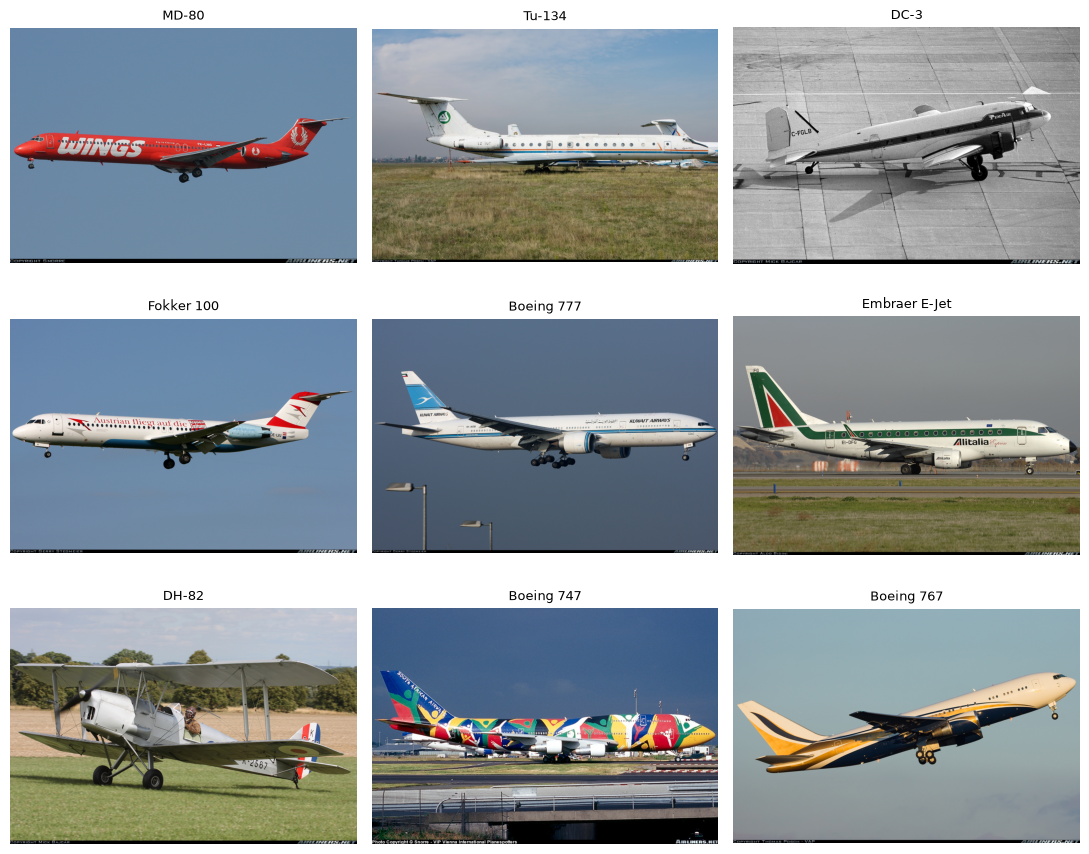

In [6]:
import random

fig, axes = plt.subplots(3, 3, figsize=(11, 9))
for ax in axes.ravel():
    img, label = ds[random.randrange(len(ds))]
    ax.imshow(img)
    ax.set_title(ds.classes[label], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Pick our 5 starter classes

We chose visually-distinct jets: **737, A320, 747, A380, 777**.
Copy their **exact** names from the cell-3 printout into the list below
(the spelling matters — e.g. it might be `Boeing 737` and `A320`).
We'll use this list in the next notebook to filter the dataset.

In [7]:
MY_CLASSES = [
    'Boeing 737',
    'A320',
    'Boeing 777',
    'A380',
    'A340'
]

# Sanity-check: make sure every name actually exists in the dataset.
for name in MY_CLASSES:
    assert name in ds.classes, f'{name!r} is NOT a valid class name — check spelling'
print('All good! Chosen classes:', MY_CLASSES)

All good! Chosen classes: ['Boeing 737', 'A320', 'Boeing 777', 'A380', 'A340']
